In [ ]:
#1 Notebook基本概念

In [25]:
print('Hello World!')

Hello World!


In [26]:
import time
time.sleep(3)

In [27]:
import numpy as np
def square(x):
    return x * x

In [28]:
x = np.random.randint(1, 10)
y = square(x)
print('%d squared is %d' % (x, y))

7 squared is 49


In [29]:
#2 熟悉基本的Python语法

In [30]:
def selection_sort(arr):
    """
    选择排序函数
    对列表 arr 进行升序排序
    """
    n = len(arr)

    for i in range(n - 1):
        min_index = i

        for j in range(i + 1, n):
            if arr[j] < arr[min_index]:
                min_index = j

        arr[i], arr[min_index] = arr[min_index], arr[i]

    return arr


def test():
    """
    测试函数
    输入数据，调用 selection_sort 函数排序，最后输出结果
    """
    data = input("请输入要排序的数据，用空格分隔：")

    nums = list(map(int, data.split()))

    result = selection_sort(nums)

    print("排序后的结果为：", result)


test()

请输入要排序的数据，用空格分隔： 64 25 12 22 11


排序后的结果为： [11, 12, 22, 25, 64]


In [31]:
#3 数据分析

In [32]:
%matplotlib inline
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [33]:
df = pd.read_csv(r"E:\backup\大学课程文件\2025-2026第二学期\软件项目研发实践\实验三\fortune500.csv")

In [34]:
df.head()

,Year,Rank,Company,Revenue (in millions),Profit (in millions)
0,1955,1,General Motors,9823.5,806
1,1955,2,Exxon Mobil,5661.4,584.8
2,1955,3,U.S. Steel,3250.4,195.4
3,1955,4,General Electric,2959.1,212.6
4,1955,5,Esmark,2510.8,19.1


In [35]:
df.tail()

,Year,Rank,Company,Revenue (in millions),Profit (in millions)
25495,2005,496,Wm. Wrigley Jr.,3648.6,493
25496,2005,497,Peabody Energy,3631.6,175.4
25497,2005,498,Wendy's International,3630.4,57.8
25498,2005,499,Kindred Healthcare,3616.6,70.6
25499,2005,500,Cincinnati Financial,3614.0,584


In [36]:
df.columns = ['year', 'rank', 'company', 'revenue', 'profit']

In [37]:
len(df)

25500

In [38]:
df.dtypes

year         int64
rank         int64
company     object
revenue    float64
profit      object
dtype: object

In [39]:
non_numberic_profits = df.profit.str.contains('[^0-9.-]')
df.loc[non_numberic_profits].head()

,year,rank,company,revenue,profit
228,1955,229,Norton,135.0,N.A.
290,1955,291,Schlitz Brewing,100.0,N.A.
294,1955,295,Pacific Vegetable Oil,97.9,N.A.
296,1955,297,Liebmann Breweries,96.0,N.A.
352,1955,353,Minneapolis-Moline,77.4,N.A.


In [40]:
len(df.profit[non_numberic_profits])

369

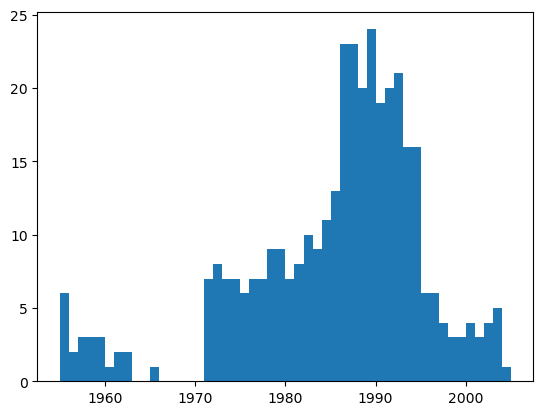

In [41]:
bin_sizes, _, _ = plt.hist(df.year[non_numberic_profits], bins=range(1955, 2006))

In [42]:
df = df.loc[~non_numberic_profits]
df.profit = df.profit.apply(pd.to_numeric)

In [43]:
len(df)

25131

In [44]:
df.dtypes

year         int64
rank         int64
company     object
revenue    float64
profit     float64
dtype: object

In [45]:
#4 数据图形绘制

In [46]:
group_by_year = df.loc[:, ['year', 'revenue', 'profit']].groupby('year')
avgs = group_by_year.mean()
x = avgs.index
y1 = avgs.profit
def plot(x, y, ax, title, y_label):
    ax.set_title(title)
    ax.set_ylabel(y_label)
    ax.plot(x, y)
    ax.margins(x=0, y=0)

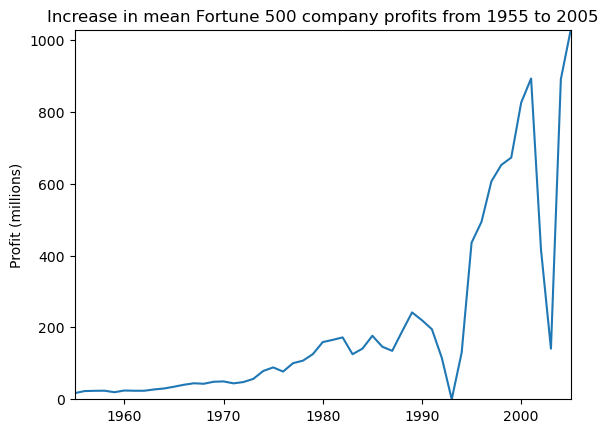

In [47]:
fig, ax = plt.subplots()
plot(x, y1, ax, 'Increase in mean Fortune 500 company profits from 1955 to 2005', 'Profit (millions)')

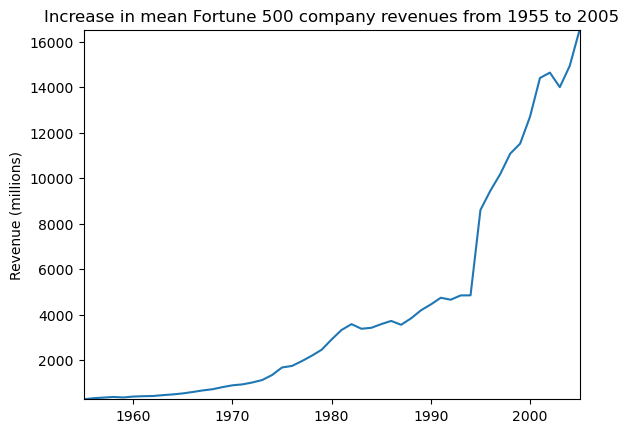

In [48]:
y2 = avgs.revenue
fig, ax = plt.subplots()
plot(x, y2, ax, 'Increase in mean Fortune 500 company revenues from 1955 to 2005', 'Revenue (millions)')

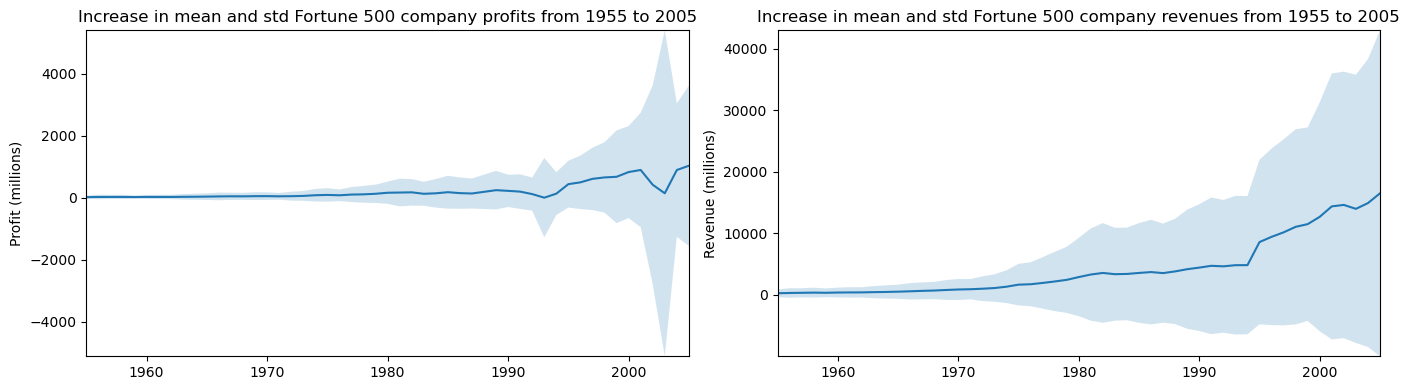

In [49]:
def plot_with_std(x, y, stds, ax, title, y_label):
    ax.fill_between(x, y - stds, y + stds, alpha=0.2)
    plot(x, y, ax, title, y_label)
fig, (ax1, ax2) = plt.subplots(ncols=2)
title = 'Increase in mean and std Fortune 500 company %s from 1955 to 2005'
stds1 = group_by_year.std().profit.values
stds2 = group_by_year.std().revenue.values
plot_with_std(x, y1.values, stds1, ax1, title % 'profits', 'Profit (millions)')
plot_with_std(x, y2.values, stds2, ax2, title % 'revenues', 'Revenue (millions)')
fig.set_size_inches(14, 4)
fig.tight_layout()

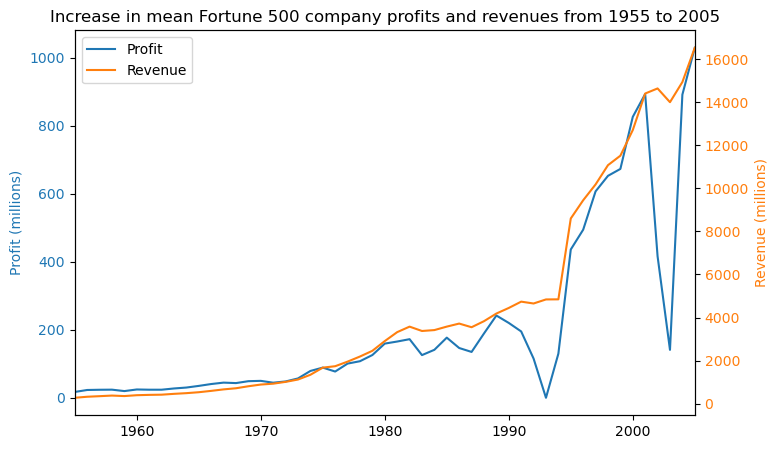

In [52]:
fig, ax1 = plt.subplots(figsize=(8, 5))

# 左侧 y 轴：利润
line1 = ax1.plot(
    x, y1,
    label='Profit',
    color='tab:blue'
)

ax1.set_ylabel('Profit (millions)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# 右侧 y 轴：收入
ax2 = ax1.twinx()

line2 = ax2.plot(
    x, y2,
    label='Revenue',
    color='tab:orange'
)

ax2.set_ylabel('Revenue (millions)', color='tab:orange')
ax2.tick_params(axis='y', labelcolor='tab:orange')

# 设置标题
ax1.set_title(
    'Increase in mean Fortune 500 company profits and revenues from 1955 to 2005'
)

# 合并图例
lines = line1 + line2
labels = [line.get_label() for line in lines]
ax1.legend(lines, labels, loc='upper left')

# 去掉左右空白
ax1.margins(x=0)
ax2.margins(x=0)

plt.show()